# Final Advanced NLP Assignment - UK Trustpilot Reviews Analysis

## Part 1: Setting Up the Problem

### a. Bibliography and SOA


We have selected the `Kerassy/trustpilot-reviews-123k` dataset from HuggingFace. This includes 123k reviews from Trustpilot UK from the 19th of December 2024 until 7th of January 2025. It covers 1,680 companies across 22 categories. 

We are approaching it from the context of a business consultancy. Specifically, we are a consulting company that advices businesses on how to improve their operations or business strategy based on insights from online customer reviews. 

Today, businesses, in particular SMEs, can see aggregate ratings (e.g., 3.6 stars) but lack detailed, scalable understanding of what is driving dissatistaction and churn (wait times, staff friendliness, prices, location, etc.) at scale and across many reviews and topics. 

Our **main objective** as a consulting business is to leverage this review dataset, containing free-text reviews, associated star ratings, business categories and use NLP methods to: 
1. predict star ratings (and potentially sentiment) from review text to detect early signals of churn
2. classify reviews into categories based on the issue
3. benchmark (1) and (2) against companies int he same category

Ultimately, providing our consulting 'customers' an actionable playbook (keep doing what you're doing well and fix what's an issue) that is linked to potential churn reduction and revenue retention.

*Note: We are assuming that customers that give ratings 3 and below are likely to not come back or "churn" due to the poor experience*

**SOA Review and Biliography**

Recent work on movie reviews, Amazon Product reviews, and Yelp, leverage pretrained Transformers such as BERT and RoBERTa with fine-tuning. These models achieve ~90%+ accuracy on primarily sentiment classification and multi class star rating prediction. The literature shows that Transformers are much better than bag of words or n-gram methods for these classifciation tasks.

Key reference papers:
1) **Universal Language Model Fine-tuning for Text Classification by Jeremy Howard and Sebastian Ruder (2018)**
   *   Propose the ULMFiT - effective transfer learning method that can be applied to any NLP task and show that their method outperforms SOA classification tasks, reducing error by 19-24%. On top of that, it performs particularly well with only 100 labeled examples (Key for the task at hand with 32 labeled examples)
   *   They specifically propose: (1) *Discriminative Fine-Tuning* (training deeper layers faster than the earlier layers), (2) *Slanted Triangular Learning Rates* (the LR adjusts in a triangle shape, speeding up its learning as it adapts to the task at hand and then slows down as it gets closer to the end) and finally,(3) *Gradual Unfreezing* (where you freeze everything but the last layer, train, then you unfreeze the layer before the last, train, then so one working end to the beginning)
   *  Link: https://arxiv.org/pdf/1801.06146v5
2) **Thumbs up? Sentiment Classification using Machine Learning Techniques Bo Pang, Lillian Lee (2002)**
   * Classic Sentiment Classification paper using moview reviews.
   * They use naive Bayes, Max Cross-Entropy models and SVMs - with SVMs being the best, but not by much. 
   * Showed that the bag of words models are not good at capturing "thwarted expectations" (I thought I'd hate the characters, the plot, the music, but in the end it was better than expected).
   * Link: https://aclanthology.org/W02-1011.pdf
3) **BERT: Pre‑training of Deep Bidirectional Transformers for Language Understanding by Jacob Devlin et al., (2019)**
   * Though not review specific, BERT fine-tuning here becomes the SOA approach for many classification tasks
   * Link: https://arxiv.org/abs/1810.04805
4) **Exploring the Limits of Transfer Learning with a Unified Text-to-Text Transformer by Raffel, Shazeer et al. (2020)**
   * This is THE paper with the highest ratings for text classification on Papers with Code, at 97.5% accuracy on the SST-2 GLUE Test
   * they showed that their text to text framework provides a simple way to train a single model on many tasks using the same loss function and decoding procedure. In spite of its simplicity, the framework obtains SOTA results for tasks like classification.
   * they found that:
     * encoder-decoder form workes best for thext to text framework
     * for training, updating all of pre-trained model parameters during fine-tuning works best, albeit most expensive. 
     * their model had 11bn parameters and they pre-trained on a multi-task mixture before they fine-tuned for individual tasks...ultimately, training their models on over 1 trillion tokens.
   * Link: https://arxiv.org/pdf/1910.10683v4

Generally, on papers with Code, for classification tasks,Transofmers, BERT and its variants achieve very high accuracy on review-classification benchmarks: 
  ![image.png](../figures/classification_leaderboard_table.png)




### b. Dataset Description 


In [1]:
SEED = 1029384756

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import sys
from pathlib import Path
import setup

os.getcwd()
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)

data_path = Path("../data/trustpilot_reviews.pkl")
if data_path.exists():
    df = pd.read_pickle(data_path)
else:
    df = setup.load_dataset_and_save_as_csv()
df.head()

,category,company,description,title,review,stars
0,Animals & Pets,ruffandtumbledogcoats.com,At Ruff and Tumble we are proud to be the mark...,Great quality dog drying robe although…,Great quality dog drying robe although had to ...,5
1,Animals & Pets,ruffandtumbledogcoats.com,At Ruff and Tumble we are proud to be the mark...,Really prompt service,"Really prompt service, The sofa covers have no...",5
2,Animals & Pets,ruffandtumbledogcoats.com,At Ruff and Tumble we are proud to be the mark...,Life saver,I’ve purchased first of those coats in May2020...,5
3,Animals & Pets,ruffandtumbledogcoats.com,At Ruff and Tumble we are proud to be the mark...,Brilliant coats,Brilliant coats. Really like the limited editi...,5
4,Animals & Pets,ruffandtumbledogcoats.com,At Ruff and Tumble we are proud to be the mark...,Great company and products,Great company and products. This is my 3rd dry...,5


### c. Random Classifier Performance



In [34]:

# packages
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report, accuracy_score
import utils as utils
from utils import Metrics



In [23]:
# preprocess the review data so that we drop certain words already identified in EDA from the reviews using the preprocess text function from utils

df["processed_review"] = df["review"].apply(utils.preprocess_text)

Random baseline accuracy: 0.0443235783577546


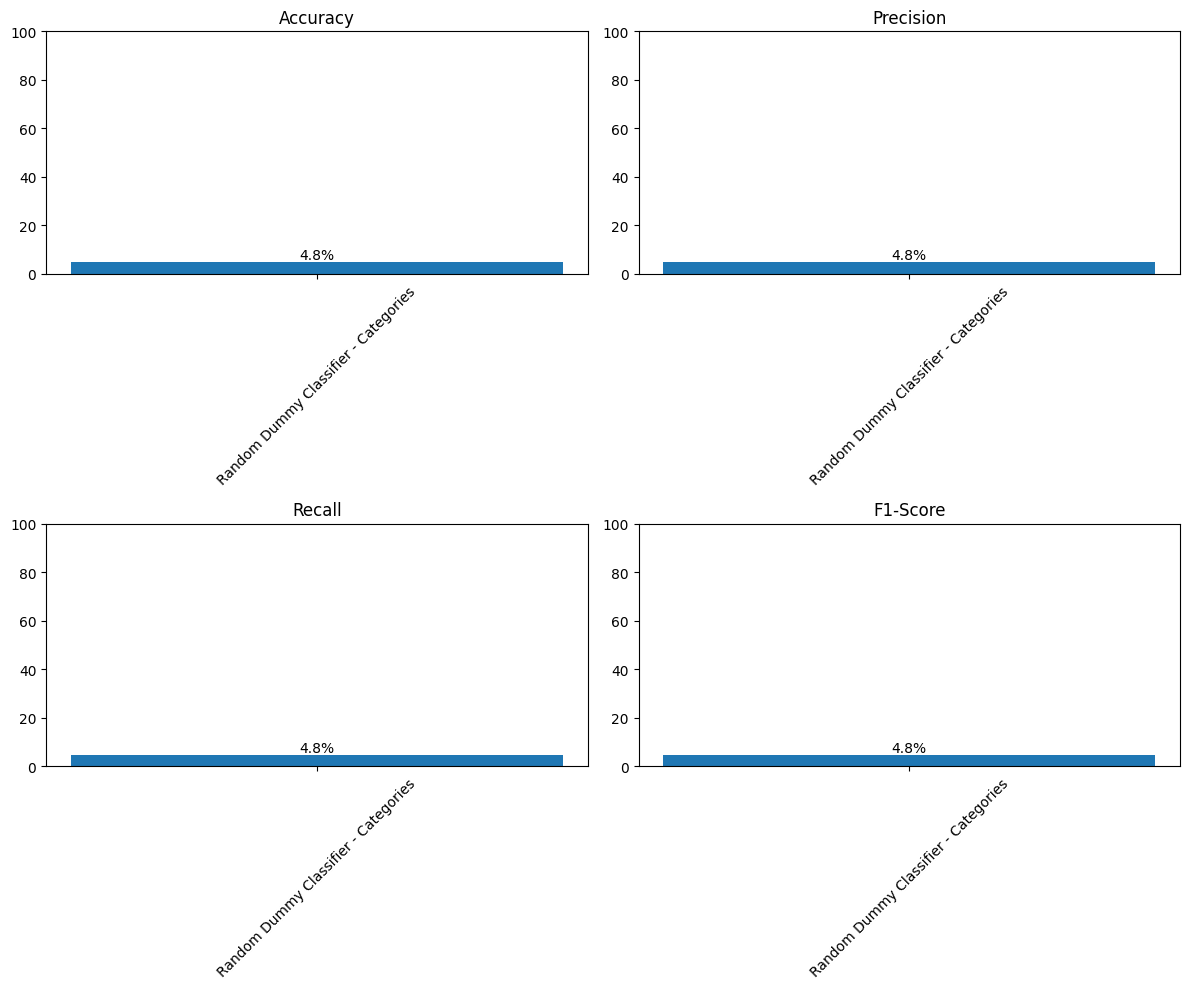

In [30]:
# use dummy classifier for baseline for all categories first


from sklearn.dummy import DummyClassifier

X_train, X_test, y_train, y_test = train_test_split(df["processed_review"], df["category"], test_size=0.2, random_state=SEED)

# join the token lists back into strings for TF-IDF
X_texts_joined = [' '.join(tokens) for tokens in X_train]
X_test_texts_joined = [' '.join(tokens) for tokens in X_test]


# Uniform random baseline
random_clf = DummyClassifier(strategy="uniform")
random_clf.fit(X_texts_joined, y_train)
y_pred = random_clf.predict(X_test_texts_joined)
print("Random baseline accuracy:", random_clf.score(X_test_texts_joined, y_test))


metrics_val = Metrics()
metrics_val.run(y_test, y_pred, "Random Dummy Classifier - Categories")
metrics_val.plot()

### Trying random forest as well

The dummy classifier gave very low metrics, testing random classifier (not purely random, but also expect it to not perform very well)

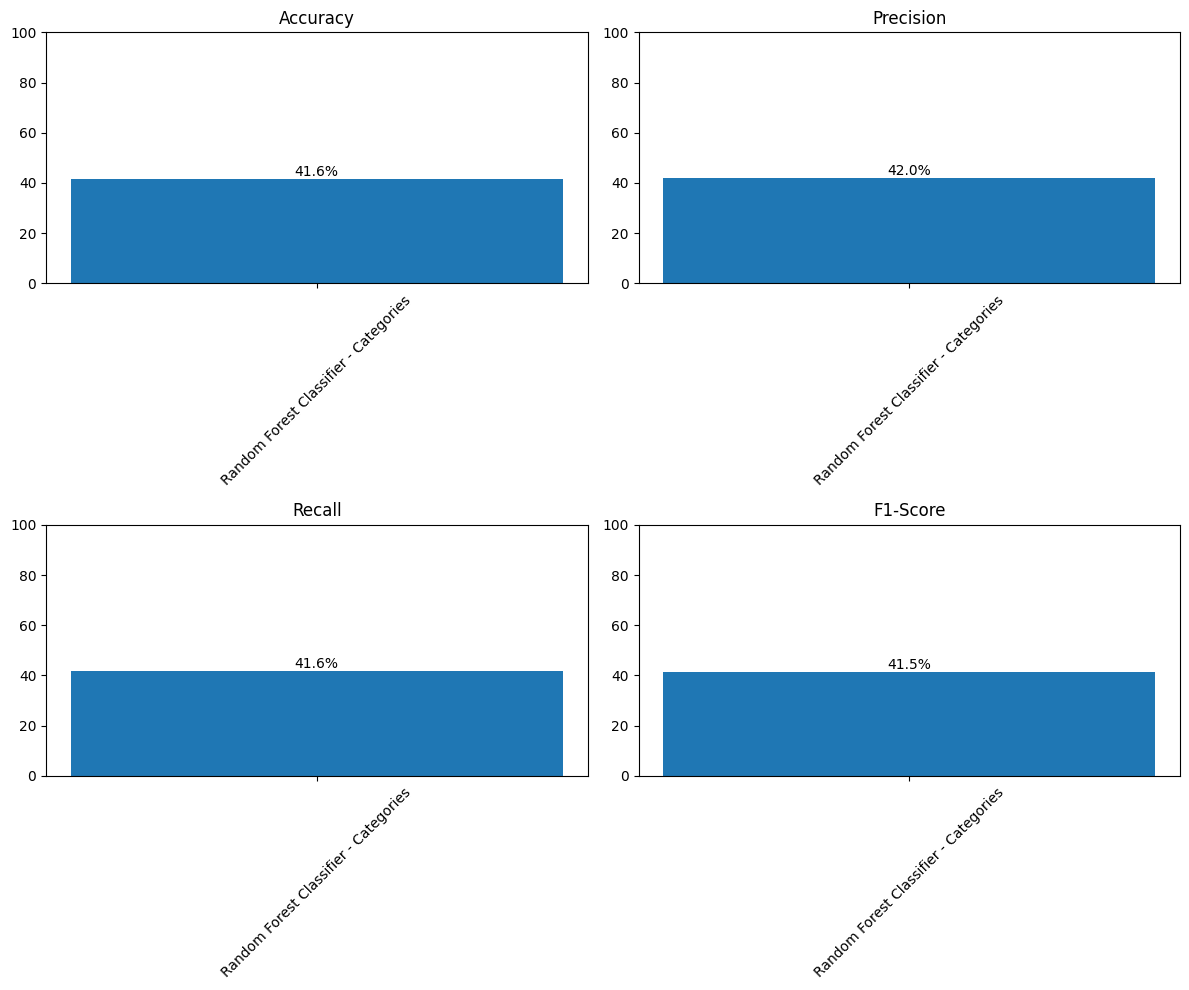

In [43]:
# AI Co-pilot assisted coding below for categories

# from the EDA we know that there are 22 categories, under "category" column

X_train, X_test, y_train, y_test = train_test_split(df["processed_review"], df["category"], test_size=0.2, random_state=SEED)

# join the token lists back into strings for TF-IDF
X_texts_joined = [' '.join(tokens) for tokens in X_train]
X_test_texts_joined = [' '.join(tokens) for tokens in X_test]

# TF-IDF baseline (trained on all labeled training data)
# n_jobs=-1 uses all CPU cores; n_estimators=50 is enough for a baseline on 123k samples
RF_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=2000, ngram_range=(1, 2))),
    ("clf", RandomForestClassifier(n_estimators=50, n_jobs=-1, random_state=SEED))])

RF_pipeline.fit(X_texts_joined, y_train)
y_pred = RF_pipeline.predict(X_test_texts_joined)


metrics_val = Metrics()
metrics_val.run(y_test, y_pred, "Random Forest Classifier - Categories")
metrics_val.plot()

### Stars Analysis

In [39]:
# ai code assisted for coding

#filter to only 2 categories - travel and media

df_filtered = df[df["category"].isin(["Travel & Vacation", "Media & Publishing"])].reset_index(drop=True)


Random baseline accuracy: 0.1924860853432282


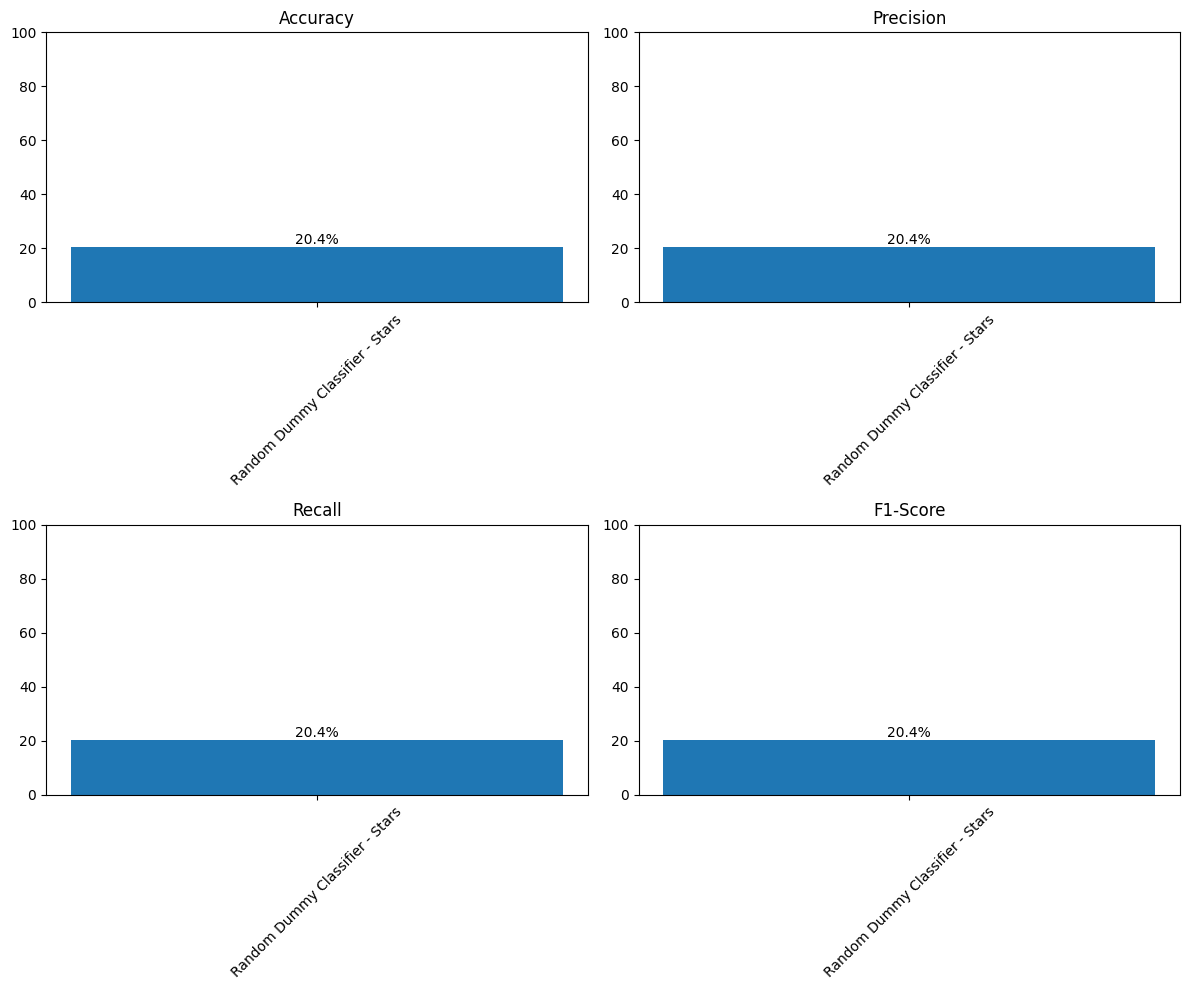

In [40]:
from sklearn.dummy import DummyClassifier

df_labeled = df_filtered[df_filtered["stars"].notnull()].copy()

X_train, X_test, y_train, y_test = train_test_split(
    df_labeled["processed_review"], df_labeled["stars"], test_size=0.2, random_state=SEED
)

# join the token lists back into strings
X_texts_joined = [' '.join(tokens) for tokens in X_train]
X_test_texts_joined = [' '.join(tokens) for tokens in X_test]

# stratified random baseline
random_clf = DummyClassifier(strategy="stratified")
random_clf.fit(X_texts_joined, y_train)
y_pred = random_clf.predict(X_test_texts_joined)
print("Random baseline accuracy:", random_clf.score(X_test_texts_joined, y_test))

metrics_val = Metrics()
metrics_val.run(y_test, y_pred, "Random Dummy Classifier - Stars")
metrics_val.plot()

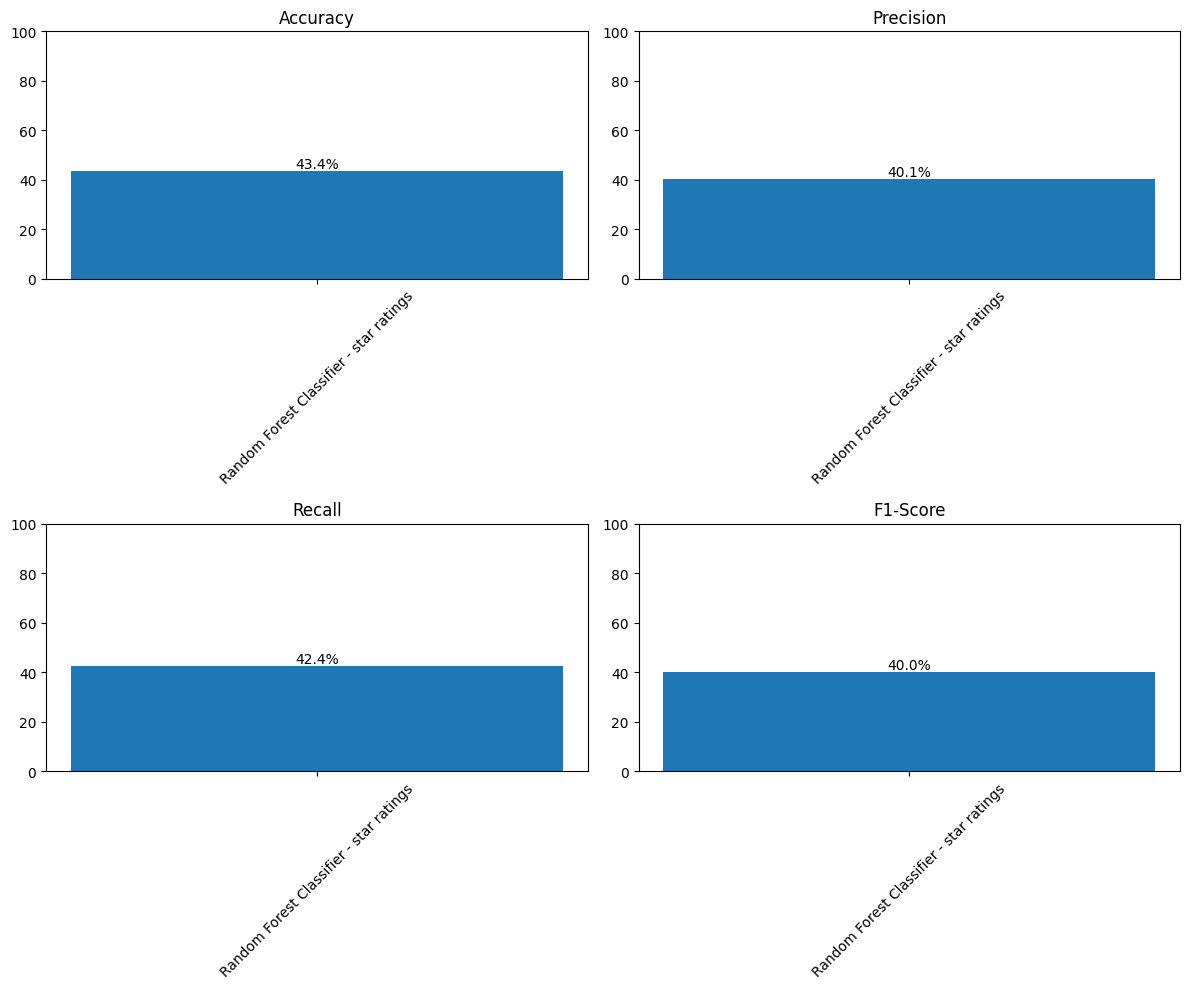

In [44]:
# AI Co-pilot assisted coding below for star ratings on specific categories
#using random forest with TF IDF

train_texts, test_texts, train_labels, test_labels = train_test_split(
    df_filtered["processed_review"], df_filtered["stars"], test_size=0.2, random_state=SEED
)

# join the token lists back into strings for TF-IDF
train_texts_joined = [' '.join(tokens) for tokens in train_texts]
test_texts_joined  = [' '.join(tokens) for tokens in test_texts]

# TF-IDF baseline (trained on all labeled training data)
RF_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=2000, ngram_range=(1, 2))),
    ("clf", RandomForestClassifier(random_state=SEED))])
RF_pipeline.fit(train_texts_joined, train_labels)
valid_preds_RF = RF_pipeline.predict(test_texts_joined)

metrics_val = Metrics()
metrics_val.run(test_labels, valid_preds_RF, 'Random Forest Classifier - star ratings')
metrics_val.plot()

In [45]:
# explore the missed classifications, showing the review text, the true label, and the predicted label for each missed classification
mask = test_labels != valid_preds_RF  # boolean Series with original df_filtered indices

missed_classifications = df_filtered.loc[test_labels.index[mask]].copy()
missed_classifications["predicted_label"] = valid_preds_RF[mask]
missed_classifications[["review", "stars", "predicted_label"]]


,review,stars,predicted_label
2255,Not happy about a surcharge of £7 being applie...,2,5
2934,Tried to change flight departure date to match...,2,1
5871,Just a general experience to be honest. After ...,3,1
6768,They sent me an entirely different book from t...,2,3
2986,It is a good way to get prices esp if you dont...,4,3
6834,Fairly informative.,4,5
10412,"I'm really impressed by your offerings, but as...",4,2
2263,website kept crashing every time I put in the ...,2,5
2075,Wouldn’t use this company again if they were t...,1,3
445,Choosing my getaway was easy but when it came ...,3,2


**Commentary**

The Dummay Classifier does expected....dummy random asignment across the 22 categories, with under 5% likelyhood to each category. Same happens for stars - 20% to each possible star rating. 

We also tried Random Forest with TF-IDF, which operates under a bag of words approach. As noted in the literature review above, this is expected to underperform SOTA. (1) As seen in the EDA, most common words are somewhat generic "service" "delivery" "company" etc (we removed this in a second iteration with the ADDITIONAL STOPWORDS) and so the adjective/context is what makes it easier to categorize the sentiment and even further the rating (2) the RF and TF-IDF struggle with the "thwarted expectations" reviews, which on intuition is likely the 2-4 star rating level (e.g."The food was great, but the service was a let down").

Additionally, recall from the EDA that this data is very balanced, with 100 reviews per company, so nuance matters to be able to distinguis anything that is 2 to 4 stars. So the model is good at catching the obvious 1s and 5 stars. Upon looking at a sample of the missed ones, as expected, these tend to fall in the middle where nuance matters most.

All in all, this ~40% baseline is a good floor...but it still means that the model is wrong on 1 of 2 predictions. This is better than always wrong, but nowhere near as good as the BERT and other Transformer models reached on classification tasks.

### d. Baseline Implementation

